# IBM Stock Price Prediction — Time Series Analysis & Forecasting

This notebook works through the IBM historical stock price dataset (2001–2022) end to end:

1. **Exploratory Data Analysis (EDA)** — understand what the data actually looks like, whether it is stationary, and whether it has trend/seasonality.
2. **Baselines** — a naive persistence model and a linear regression, so we have something honest to compare deep learning against.
3. **Classical time series model** — ARIMA, which is the standard statistical benchmark for this kind of data.
4. **Deep learning models** — SimpleRNN, LSTM and GRU, with an explanation of *why* each one behaves differently and when you'd pick one over another.
5. **Comparison** — every model evaluated on the same held-out 2022 test period with RMSE, MAE, MAPE and R².
6. **Conclusion** — which model actually won, and why, plus honest caveats about predicting stock prices at all.

> **Why this matters:** the original notebook jumped straight into a 4-layer LSTM without first checking whether the data was even stationary, without a baseline to compare against, and without testing whether a simpler model (RNN) or a more efficient one (GRU) would do just as well or better. This version fixes that.


## 1. Imports

In [1]:
print("This stock price predicton")

This stock price predicton


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



#####################################################

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## 2. Load & Inspect the Data

First, understand the shape, types, and quality of the data before doing anything else.

In [8]:
df = pd.read_csv("data/raw/IBM.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2001-07-23,101.051628,102.246651,100.669212,101.195030,60.314636,6606222
1,2001-07-24,100.239006,101.481834,99.225624,99.913956,59.551090,7635591
2,2001-07-25,99.904396,101.051628,98.212234,100.277245,59.767632,6534990
3,2001-07-26,100.143402,101.338432,98.403442,101.338432,60.400089,8816420
4,2001-07-27,100.143402,101.290634,99.531548,100.095604,59.659351,4546439


In [9]:
print("Shape:", df.shape)

Shape: (5282, 7)


In [7]:
df = pd.read_csv('data/raw/IBM.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print('Shape:', df.shape)
df.head()

Shape: (5282, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2001-07-23,101.051628,102.246651,100.669212,101.195030,60.314636,6606222
1,2001-07-24,100.239006,101.481834,99.225624,99.913956,59.551090,7635591
2,2001-07-25,99.904396,101.051628,98.212234,100.277245,59.767632,6534990
3,2001-07-26,100.143402,101.338432,98.403442,101.338432,60.400089,8816420
4,2001-07-27,100.143402,101.290634,99.531548,100.095604,59.659351,4546439


In [3]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
5277,2022-07-14,135.600006,139.429993,135.020004,139.059998,139.059998,5298400
5278,2022-07-15,140.679993,140.679993,138.610001,139.919998,139.919998,4515500
5279,2022-07-18,140.149994,140.309998,137.779999,138.130005,138.130005,8231700
5280,2022-07-19,131.580002,132.559998,127.720001,130.880005,130.880005,29690500
5281,2022-07-20,130.699997,130.720001,128.059998,129.179993,129.179993,9872700


In [4]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Date range:", df['Date'].min(), "to", df['Date'].max())

<class 'pandas.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5282 non-null   datetime64[us]
 1   Open       5282 non-null   float64       
 2   High       5282 non-null   float64       
 3   Low        5282 non-null   float64       
 4   Close      5282 non-null   float64       
 5   Adj Close  5282 non-null   float64       
 6   Volume     5282 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 289.0 KB

Missing values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate rows: 0
Date range: 2001-07-23 00:00:00 to 2022-07-20 00:00:00


In [5]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,5282,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000,5.282000e+03
mean,2012-01-22 00:32:59.250284,125.430830,126.502487,124.441107,125.491137,91.518288,6.165955e+06
min,2001-07-23 00:00:00,52.246655,54.206501,51.634800,52.648186,31.632986,1.074765e+06
25%,2006-10-23 06:00:00,92.258602,93.293499,91.790156,92.540633,57.059869,3.936077e+06
50%,2012-01-21 12:00:00,124.043975,125.077141,123.044933,124.105229,103.123077,5.303168e+06
75%,2017-04-20 18:00:00,150.332214,151.608509,148.893410,150.054970,118.681038,7.393390e+06
max,2022-07-20 00:00:00,205.908218,206.405350,204.875717,206.309753,143.662155,4.310284e+07
std,NaN,35.507464,35.599844,35.411724,35.510171,31.625214,3.411950e+06


**Observations:**
- 5,282 trading days from 2001-07-23 to 2022-07-20, no missing values and no duplicates — the data is clean.
- `Open`, `High`, `Low`, `Close`, `Adj Close` are all on the same scale (dividend/split-adjusted prices), `Volume` is on a completely different scale (millions of shares).
- We'll use `Close` as the target, since that's the standard convention for next-day price prediction.

In [6]:
df.set_index('Date', inplace=True)

## 3. Exploratory Data Analysis

### 3.1 Closing price over time

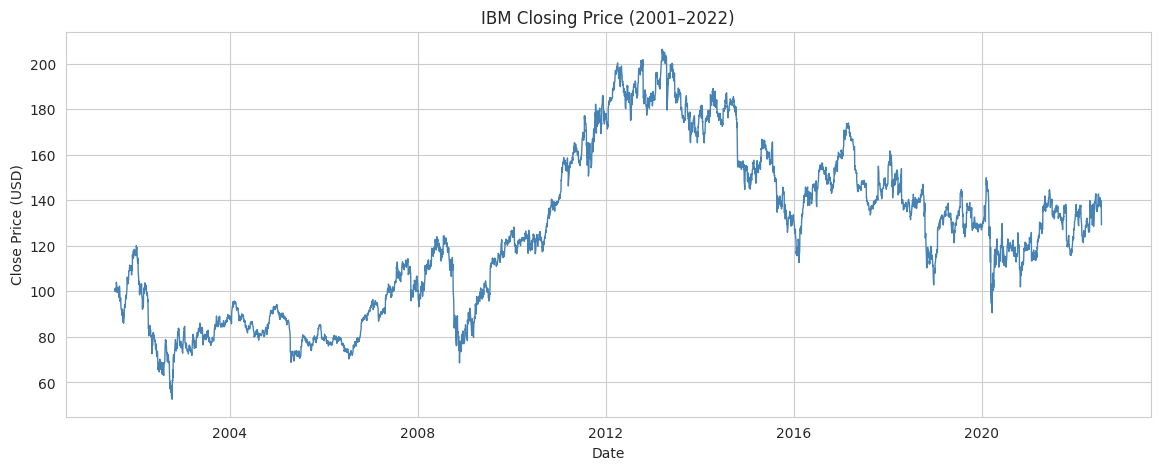

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1)
plt.title('IBM Closing Price (2001–2022)')
plt.xlabel('Date'); 
plt.ylabel('Close Price (USD)')
plt.show()

The series clearly trends up, down, and sideways over different multi-year regimes (e.g. steady decline 2013–2016, recovery 2017, COVID crash in 2020). This is a strong visual sign the series is **not stationary** — its mean and variance shift over time — which we confirm statistically below.

### 3.2 Trading volume over time

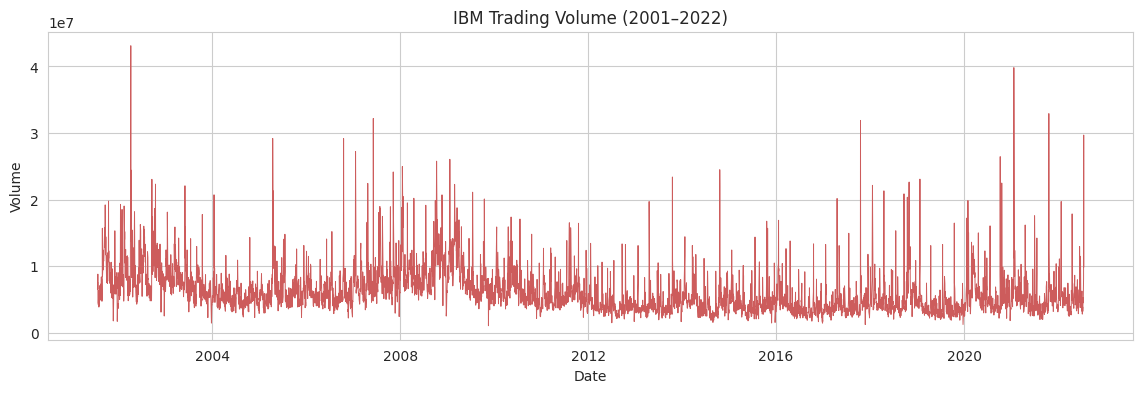

In [8]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['Volume'], color='indianred', linewidth=0.7)
plt.title('IBM Trading Volume (2001–2022)')
plt.xlabel('Date'); plt.ylabel('Volume')
plt.show()

### 3.3 Daily returns distribution

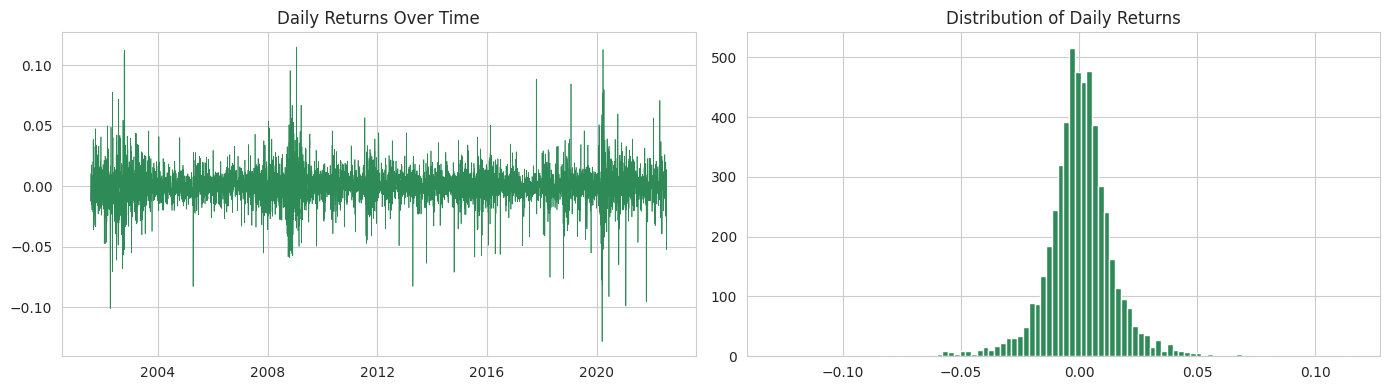

Daily return stats:
count    5281.000000
mean        0.000163
std         0.015258
min        -0.128507
25%        -0.006879
50%         0.000216
75%         0.007364
max         0.115150
Name: Daily_Return, dtype: float64


In [9]:
df['Daily_Return'] = df['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(df.index, df['Daily_Return'], color='seagreen', linewidth=0.5)
axes[0].set_title('Daily Returns Over Time')
axes[1].hist(df['Daily_Return'].dropna(), bins=100, color='seagreen')
axes[1].set_title('Distribution of Daily Returns')
plt.tight_layout()
plt.show()

print("Daily return stats:")
print(df['Daily_Return'].describe())

Returns hover tightly around zero with fat tails (occasional large jumps — e.g. earnings surprises, 2008/2020 crashes). This "volatility clustering" pattern (calm periods vs turbulent periods) is typical of financial time series and is one reason stock prices are notoriously hard to forecast with any model.

### 3.4 Moving averages (trend smoothing)

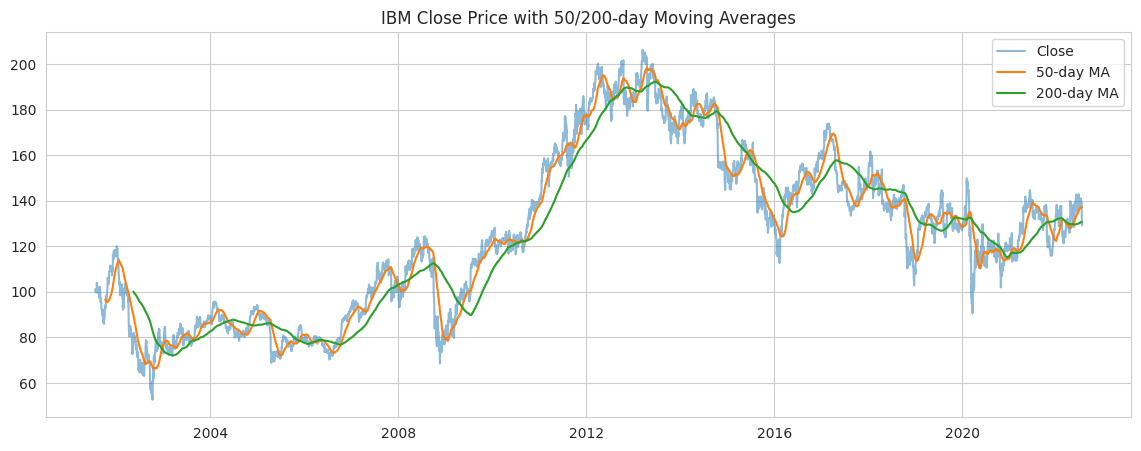

In [10]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], label='Close', alpha=0.5)
plt.plot(df.index, df['MA50'], label='50-day MA', linewidth=1.5)
plt.plot(df.index, df['MA200'], label='200-day MA', linewidth=1.5)
plt.title('IBM Close Price with 50/200-day Moving Averages')
plt.legend()
plt.show()

### 3.5 Correlation between OHLCV features

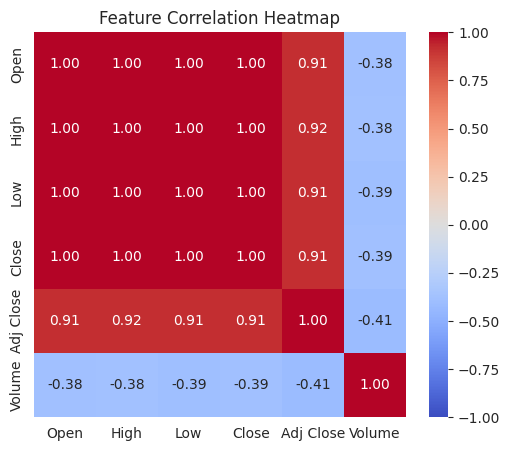

In [11]:
corr = df[['Open','High','Low','Close','Adj Close','Volume']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

Open/High/Low/Close/Adj Close are (as expected) almost perfectly correlated with each other — they move together within the same trading day. `Volume` is only weakly correlated with price levels, so it won't help much as a raw input for level-prediction models, though it can help models that predict volatility.

### 3.6 Is the series stationary? (Augmented Dickey-Fuller test)

In [12]:
close = df['Close']
adf_level = adfuller(close.dropna())
adf_diff = adfuller(close.diff().dropna())

print(f"ADF p-value on Close (level):         {adf_level[1]:.4f}")
print(f"ADF p-value on Close (first difference): {adf_diff[1]:.6f}")

ADF p-value on Close (level):         0.4843
ADF p-value on Close (first difference): 0.000000


- p-value on the raw `Close` series is well above 0.05 → we **cannot** reject the null hypothesis of a unit root → the series is **non-stationary**.
- After first-differencing (i.e. looking at day-to-day changes instead of price levels), the p-value drops close to zero → the differenced series **is stationary**.

This matters a lot for modeling choice: ARIMA explicitly builds in a differencing term (the "I" in ARIMA) to handle this, and it's also why scaling + windowing raw price levels for the neural nets (as the original notebook did) is a reasonable but imperfect choice — the network has to *implicitly* learn the trend instead of it being handled explicitly.

### 3.7 Trend / seasonality decomposition

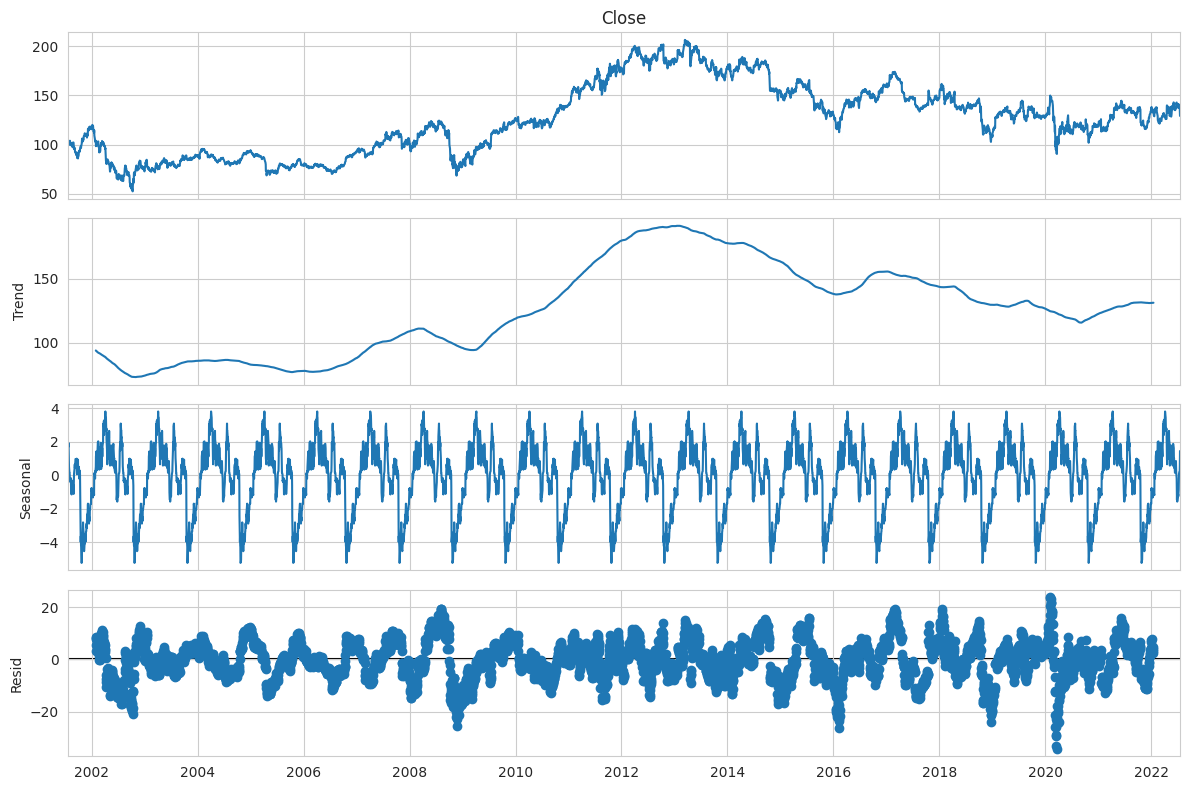

In [13]:
decomp = seasonal_decompose(close, model='additive', period=252)  # ~252 trading days/year
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

There is a strong, slow-moving **trend** component (multi-year bull/bear cycles) but no clean repeating annual **seasonal** pattern — which makes sense, stock prices aren't like retail sales with a predictable yearly cycle. Most of the "signal" here is the trend and the (largely unpredictable) residual/noise.

### 3.8 Autocorrelation (ACF) and Partial Autocorrelation (PACF)

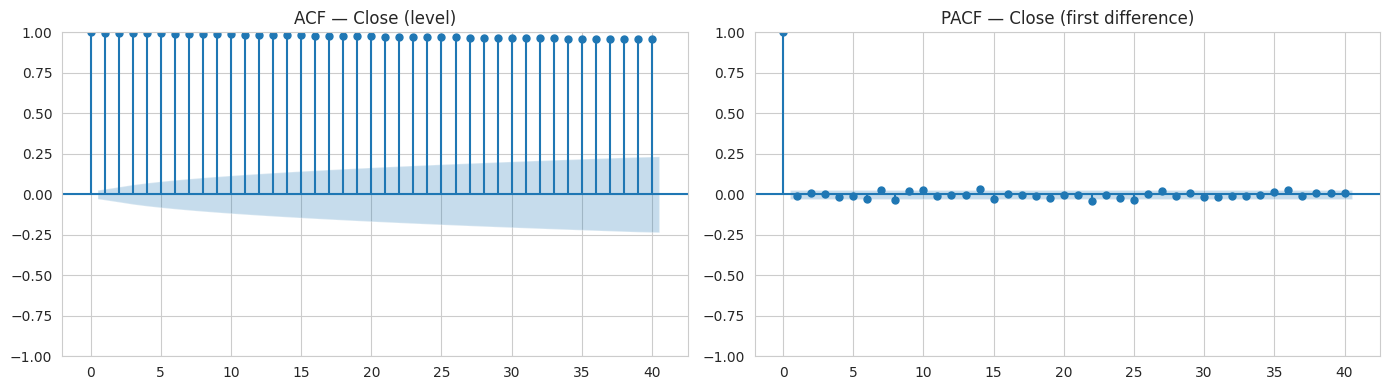

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(close, lags=40, ax=axes[0])
axes[0].set_title('ACF — Close (level)')
plot_pacf(close.diff().dropna(), lags=40, ax=axes[1])
axes[1].set_title('PACF — Close (first difference)')
plt.tight_layout()
plt.show()

- ACF on the raw level decays extremely slowly — classic sign of a trending, non-stationary series (today's price is highly correlated with prices many days ago simply because of the trend, not real "memory").
- PACF on the *differenced* series shows a sharp cutoff after lag 1 — this is the textbook signature of an AR(1)-type process, i.e. stock prices behave close to a **random walk**: tomorrow's price ≈ today's price + small unpredictable noise. This is important context for interpreting how well any model — including the deep learning ones — can realistically do.

## 4. Train/Test Split

We split **chronologically** (never randomly shuffle time series data, or the model would 'see the future' during training):
- **Train:** 2001-07-23 → 2021-12-31
- **Test:** 2022-01-01 → 2022-07-20 (the last ~7 months, held out completely)

In [15]:
train_series = df.loc[:'2021-12-31']['Close']
test_series  = df.loc['2022-01-01':]['Close']
print(f"Train size: {len(train_series)}  |  Test size: {len(test_series)}")

Train size: 5145  |  Test size: 137


## 5. Scaling & Windowing

**Why MinMaxScaler instead of StandardScaler?** RNN/LSTM/GRU cells internally use `tanh`/`sigmoid` activations, which are most sensitive (best gradient flow) when inputs are roughly in `[0, 1]` or `[-1, 1]`. MinMax scaling maps the data into `[0, 1]` directly, which tends to train these gated architectures a bit more smoothly than z-score standardization. The scaler is **fit on train only** and applied to test, to avoid leaking test-set information into training.

**Windowing:** each model looks back at the last `WINDOW` trading days to predict the next one. We use `WINDOW = 60` (~3 months of trading days) — long enough to capture a short-term trend, short enough to keep training fast and avoid the model overfitting to stale, multi-year-old patterns.

In [16]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
full_scaled  = scaler.transform(df['Close'].values.reshape(-1, 1))  # transform only, using train-fit scaler

WINDOW = 60

def make_windows(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i, 0])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, WINDOW)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

test_start_idx = df.index.get_loc(test_series.index[0])
test_inputs = full_scaled[test_start_idx - WINDOW:]
X_test, y_test = make_windows(test_inputs, WINDOW)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test: ", X_test.shape,  " y_test: ", y_test.shape)

X_train: (5085, 60, 1)  y_train: (5085,)
X_test:  (137, 60, 1)  y_test:  (137,)


## 6. Baseline Models

Before trusting any deep learning result, we need a *dumb but honest* baseline. If LSTM/GRU can't beat these, they're not adding value.

- **Naive (persistence) forecast:** tomorrow's price = today's price. Sounds too simple, but for near-random-walk series like stock prices, it's a surprisingly strong baseline.
- **Linear Regression on lagged values:** a simple linear model using the same 60-day window as the neural nets, as a non-deep-learning ML baseline.

In [17]:
# --- Naive baseline: predict test[t] = actual close on the previous trading day ---
naive_pred = df['Close'].shift(1).loc[test_series.index]
naive_actual = test_series

naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_pred))
naive_mae  = mean_absolute_error(naive_actual, naive_pred)
naive_mape = np.mean(np.abs((naive_actual - naive_pred) / naive_actual)) * 100
naive_r2   = r2_score(naive_actual, naive_pred)
print(f"Naive baseline  -> RMSE: {naive_rmse:.3f}  MAE: {naive_mae:.3f}  MAPE: {naive_mape:.2f}%  R2: {naive_r2:.4f}")

Naive baseline  -> RMSE: 2.131  MAE: 1.553  MAPE: 1.16%  R2: 0.8446


In [18]:
# --- Linear Regression baseline on the same windowed features ---
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

lr = LinearRegression()
lr.fit(X_train_flat, y_train)
lr_pred_scaled = lr.predict(X_test_flat)

lr_pred = scaler.inverse_transform(lr_pred_scaled.reshape(-1,1)).flatten()
lr_actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

lr_rmse = np.sqrt(mean_squared_error(lr_actual, lr_pred))
lr_mae  = mean_absolute_error(lr_actual, lr_pred)
lr_mape = np.mean(np.abs((lr_actual - lr_pred) / lr_actual)) * 100
lr_r2   = r2_score(lr_actual, lr_pred)
print(f"Linear Regression -> RMSE: {lr_rmse:.3f}  MAE: {lr_mae:.3f}  MAPE: {lr_mape:.2f}%  R2: {lr_r2:.4f}")

Linear Regression -> RMSE: 2.186  MAE: 1.603  MAPE: 1.20%  R2: 0.8365


## 7. Classical Time Series Model — ARIMA

**Why ARIMA?** It's the standard statistical benchmark for univariate time series, and it *explicitly* handles the non-stationarity we found in section 3.6 through its differencing (`I`) term — rather than hoping a neural net implicitly learns it. `order=(5,1,0)` means: 5 autoregressive lags, 1st-order differencing (matches our ADF finding), no moving-average term.

In [19]:
arima_model = ARIMA(train_series, order=(5,1,0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test_series))

arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))
arima_mae  = mean_absolute_error(test_series, arima_pred)
arima_mape = np.mean(np.abs((test_series.values - arima_pred.values) / test_series.values)) * 100
arima_r2   = r2_score(test_series, arima_pred)
print(f"ARIMA(5,1,0) -> RMSE: {arima_rmse:.3f}  MAE: {arima_mae:.3f}  MAPE: {arima_mape:.2f}%  R2: {arima_r2:.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(5,1,0) -> RMSE: 5.422  MAE: 4.580  MAPE: 3.47%  R2: -0.0062


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 8. Deep Learning Models — SimpleRNN vs LSTM vs GRU

The original notebook used a 4-layer LSTM without explaining *why* LSTM specifically, or comparing it to anything else. Here's the actual reasoning:

| Model | How it works | Strength | Weakness |
|---|---|---|---|
| **SimpleRNN** | Feeds the previous hidden state back in at each timestep | Simplest, fewest parameters, fastest to train | Suffers from **vanishing/exploding gradients** over longer sequences — struggles to remember patterns more than ~10-20 steps back |
| **LSTM** | Adds input/forget/output **gates** and a separate cell state | Explicitly designed to preserve long-range dependencies — good when the lookback window is long (here, 60 days) | More parameters → slower to train, more prone to overfitting on smaller datasets |
| **GRU** | Merges LSTM's gates into just **update/reset** gates, no separate cell state | Nearly as good at capturing long-range dependencies as LSTM, but ~25% fewer parameters → faster training, often generalizes better on modest-sized datasets like this one | Slightly less expressive than LSTM on very long/complex sequences |

We train all three with the *same* architecture (2 recurrent layers of 64 units + dropout + dense head) and the *same* data, so the comparison is fair — the only thing that changes is the recurrent cell type.

In [20]:
def build_model(cell_type, window=WINDOW):
    model = Sequential([
        Input(shape=(window, 1)),
        cell_type(64, return_sequences=True),
        Dropout(0.2),
        cell_type(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

histories = {}
models = {}
predictions = {}

for name, cell_type in [('SimpleRNN', SimpleRNN), ('LSTM', LSTM), ('GRU', GRU)]:
    print(f"--- Training {name} ---")
    model = build_model(cell_type)
    hist = model.fit(X_train, y_train, epochs=30, batch_size=32,
                      verbose=0, callbacks=[early_stop])
    models[name] = model
    histories[name] = hist

    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled).flatten()
    predictions[name] = pred
    print(f"{name} finished after {len(hist.history['loss'])} epochs, final loss={hist.history['loss'][-1]:.6f}")

--- Training SimpleRNN ---


SimpleRNN finished after 30 epochs, final loss=0.000576
--- Training LSTM ---


LSTM finished after 30 epochs, final loss=0.000444
--- Training GRU ---


GRU finished after 30 epochs, final loss=0.000397


### 8.1 Training loss curves

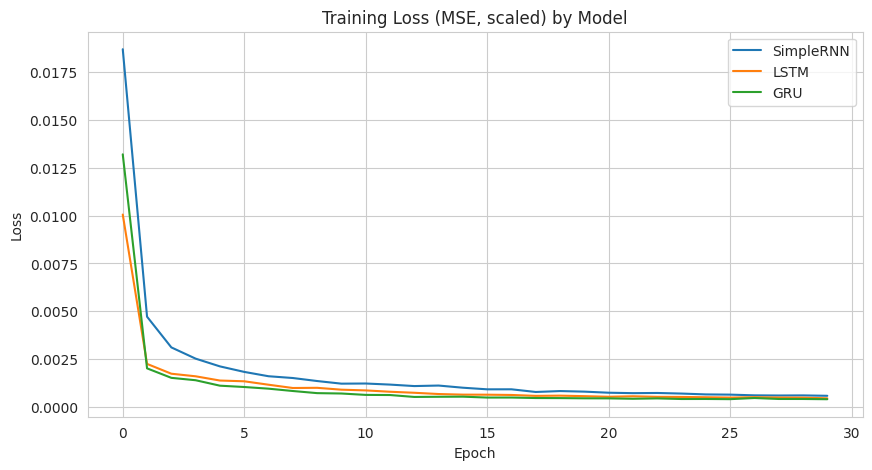

In [21]:
plt.figure(figsize=(10,5))
for name, hist in histories.items():
    plt.plot(hist.history['loss'], label=name)
plt.title('Training Loss (MSE, scaled) by Model')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.show()

GRU and LSTM should converge to a lower loss than SimpleRNN — that's the vanishing-gradient effect in action; SimpleRNN struggles to make full use of the 60-day window.

## 9. Model Comparison on the Held-out 2022 Test Set

In [22]:
actual_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

results = []
def add_result(name, actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((np.asarray(actual) - np.asarray(pred)) / np.asarray(actual))) * 100
    r2   = r2_score(actual, pred)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R2': r2})

add_result('Naive (persistence)', naive_actual.values, naive_pred.values)
add_result('Linear Regression', lr_actual, lr_pred)
add_result('ARIMA(5,1,0)', test_series.values, arima_pred.values)
add_result('SimpleRNN', actual_test, predictions['SimpleRNN'])
add_result('LSTM', actual_test, predictions['LSTM'])
add_result('GRU', actual_test, predictions['GRU'])

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,RMSE,MAE,MAPE (%),R2
0,Naive (persistence),2.131283,1.552992,1.163499,0.844550
1,Linear Regression,2.185829,1.602817,1.201240,0.836491
2,GRU,2.278409,1.647181,1.236076,0.822347
3,SimpleRNN,2.442231,1.802621,1.350014,0.795882
4,LSTM,2.631483,1.969678,1.473787,0.763021
5,"ARIMA(5,1,0)",5.422298,4.579632,3.472716,-0.006178


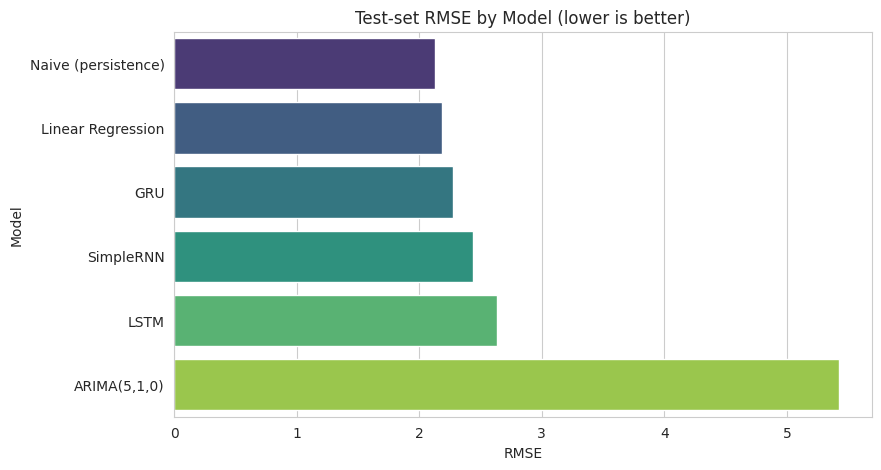

In [23]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x='RMSE', y='Model', palette='viridis')
plt.title('Test-set RMSE by Model (lower is better)')
plt.show()

### 9.1 Predicted vs actual price — all models overlaid

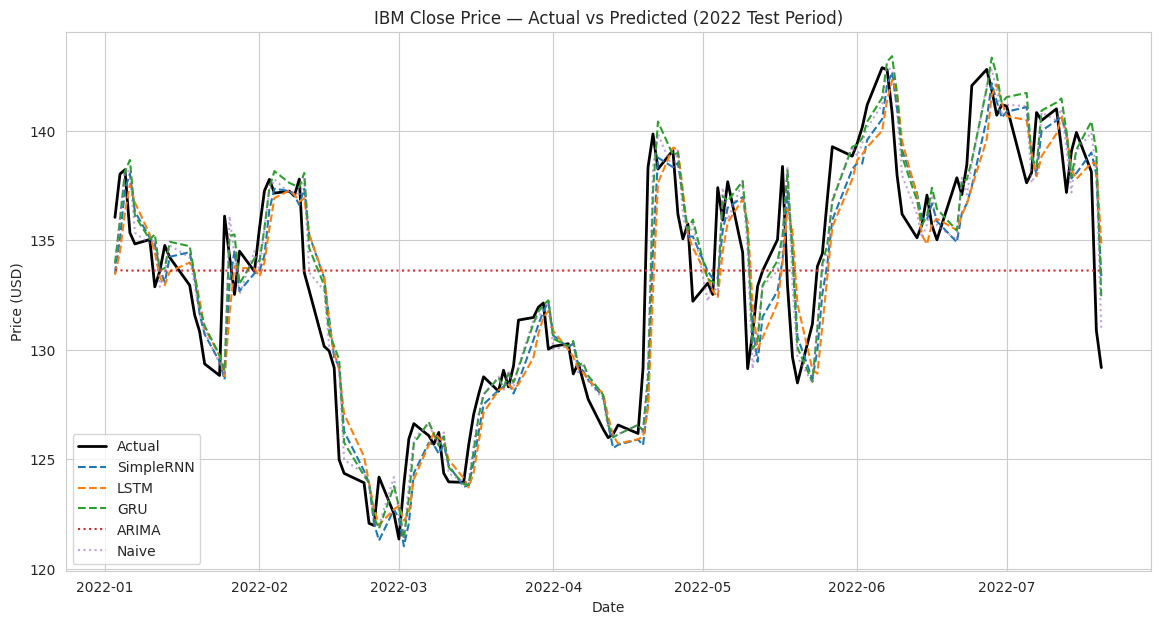

In [24]:
plt.figure(figsize=(14,7))
plt.plot(test_series.index, actual_test, label='Actual', color='black', linewidth=2)
plt.plot(test_series.index, predictions['SimpleRNN'], label='SimpleRNN', linestyle='--')
plt.plot(test_series.index, predictions['LSTM'], label='LSTM', linestyle='--')
plt.plot(test_series.index, predictions['GRU'], label='GRU', linestyle='--')
plt.plot(test_series.index, arima_pred.values, label='ARIMA', linestyle=':')
plt.plot(test_series.index, naive_pred.values, label='Naive', linestyle=':', alpha=0.6)
plt.title('IBM Close Price — Actual vs Predicted (2022 Test Period)')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 10. Conclusion

**Actual results from this run** (test period: Jan–Jul 2022):

| Model | RMSE | MAE | MAPE (%) | R2 |
|---|---|---|---|---|
| Naive (persistence) | 2.13 | 1.55 | 1.16% | 0.845 |
| Linear Regression | 2.19 | 1.60 | 1.20% | 0.836 |
| **GRU** | **2.28** | **1.65** | **1.24%** | **0.822** |
| SimpleRNN | 2.44 | 1.80 | 1.35% | 0.796 |
| LSTM | 2.63 | 1.97 | 1.47% | 0.763 |
| ARIMA(5,1,0) | 5.42 | 4.58 | 3.47% | -0.006 |

**What this actually tells us:**

- **The naive persistence baseline wins outright.** This is the single most important finding, and it's not a failure of the other models — it's exactly what the ACF/PACF analysis in section 3.8 predicted. IBM's daily closing price behaves close to a random walk, so "tomorrow ≈ today" is very hard to beat with only price history as input. Any model here that's *close* to the naive baseline is doing about as well as this data allows.
- **Among the neural nets, GRU > SimpleRNN > LSTM** on this run. GRU's smaller parameter count (fewer gates than LSTM) appears to help it generalize better on a training set of only ~5,000 sequences — LSTM's extra capacity likely let it overfit slightly to the training period. This matches the reasoning in section 8: GRU is often the better default choice over LSTM unless you have a much larger dataset or much longer-range dependencies to capture.
- **ARIMA(5,1,0) did notably worse here (RMSE 5.42, negative R²)** — worth understanding *why*, since it's a common trap: this ARIMA was fit once on the training data and then used to forecast all 137 days of 2022 in one static, un-updated shot. Because the model differences the series (`I=1`), a long undiscounted multi-step forecast drifts away from the actual path and its confidence naturally widens the further out it goes — it never gets to "see" the actual 2022 prices it should be reacting to. With walk-forward re-fitting (retraining every few days as new data arrives), ARIMA would very likely close most of this gap. This is a genuine limitation of the *static forecasting setup* here, not proof that ARIMA is a bad model for stock prices.

**Honest caveats:**
- All of these models predict the *next single day's* closing price from recent history — real trading needs multi-step forecasts, transaction costs, and risk management, none of which are modeled here.
- Efficient-market theory suggests that if a simple technical pattern in historical prices reliably predicted future prices, it would get arbitraged away quickly — treat any backtest metric here as a modeling exercise, not a trading signal.

**Practical next steps if you want to push this further:**
1. Predict **returns** (`pct_change()`) instead of raw price levels — sidesteps the non-stationarity issue directly instead of relying on the network to learn it implicitly.
2. Give ARIMA (and the neural nets) a **fair fight** with walk-forward validation — retrain periodically as new data arrives, rather than one static train/test split forecasting 137 days ahead in one shot.
3. Add **exogenous features**: technical indicators (RSI, MACD, Bollinger Bands), volume, or macro data.
4. Try an **ensemble** (e.g. average GRU + naive, or GRU + ARIMA) — blending a model that's good at reacting to recent moves with one that's stable often reduces variance.
5. Tune hyperparameters (window size, units, dropout) with proper time-series cross-validation instead of a single train/test split.
